In [1]:
import pandas as ps
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
features = ["pclass","sex","fare","embarked","age"]
targer = ["survived"]

In [4]:
# Missing Values fill
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [5]:
# incoding 
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [6]:
# train test split
x = titanic[features]
y = titanic[targer]

X_train,X_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [7]:
# Decision tree model - no pruning
model = DecisionTreeClassifier(max_depth=6, min_samples_split=10)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6, min_samples_split=10)

In [8]:
# predict model accuracy 
y_pred = model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.8100558659217877


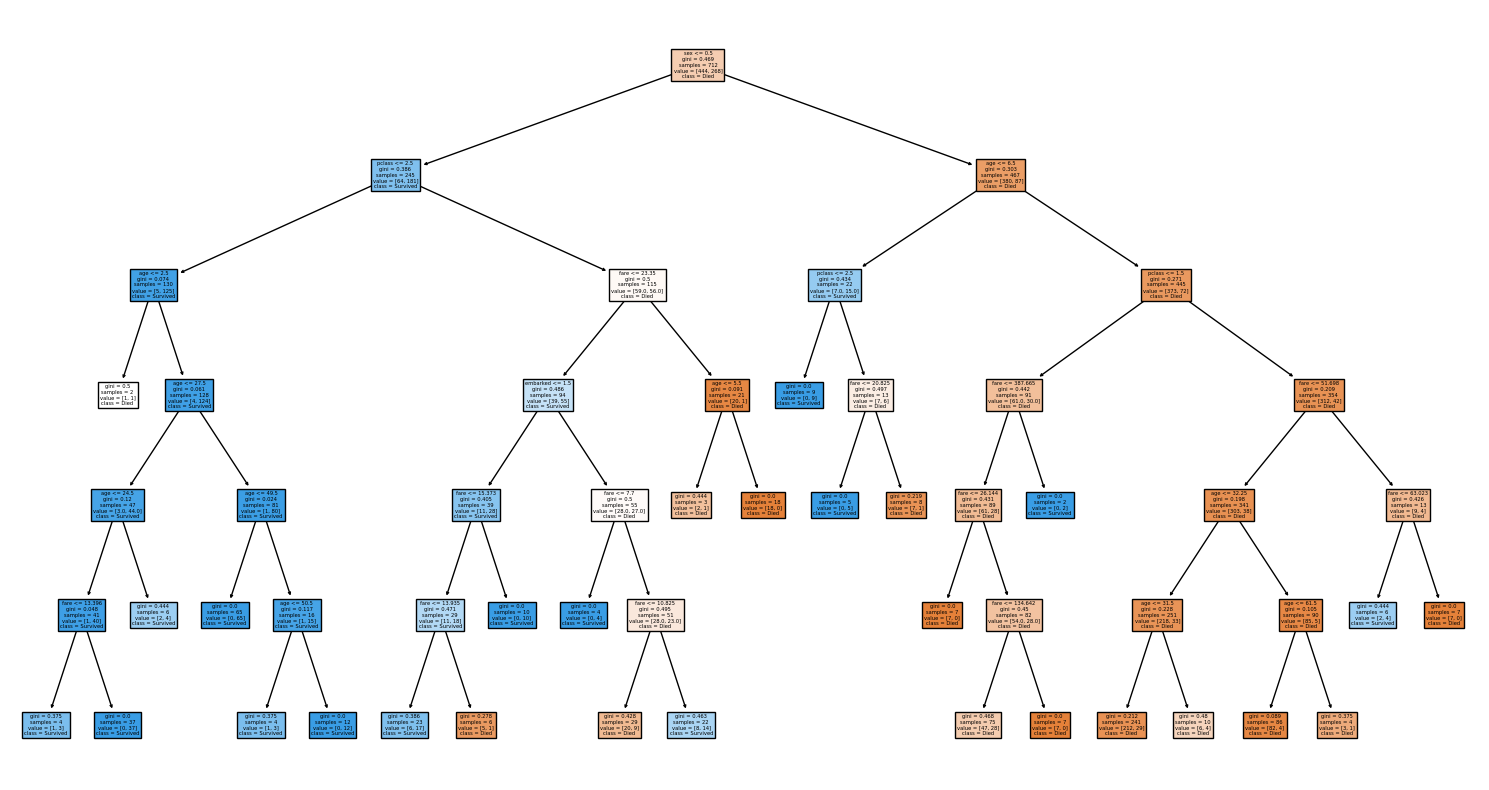

In [11]:
# Visualization in DecisionTreeClassifier
plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled = True,
    # max_depth=3
)
plt.tight_layout()
plt.show()

In [10]:
# Decision tree model - pre pruning
# max_depth = [2,3,4,5,6,7,8,9,10]
# min_sampal_split = [5,10,15,20,25,30]
# for split in min_sampal_split:
#     model = DecisionTreeClassifier(max_depth=6, min_samples_split=split)
#     model.fit(X_train,y_train)
#     y_pred = model.score(X_test,y_test)
#     print(f"accuracy{split}:", y_pred)